# EDA и моделирование — Predictive Maintenance
# EDA and Modeling — Predictive Maintenance

Разведочный анализ данных и подготовка к построению модели бинарной классификации отказов оборудования.  
Exploratory data analysis and preparation for binary failure classification.

## План работы / Work plan

1. **Загрузка данных** — чтение CSV из `data/raw/`.
2. **Базовая информация** — shape, колонки, типы, пропуски.
3. **Первые строки** — быстрый обзор структуры записей.
4. **Матрица корреляции** — heatmap числовых признаков.
5. **Целевая переменная** — распределение `Target` (0 — нет отказа, 1 — отказ).
6. **Предобработка** — кодирование признаков, train/test split, стандартизация.
7. **Baseline-модель** — Logistic Regression, метрики и confusion matrix.
8. **Random Forest** — сравнение с baseline по F1-score.
9. **XGBoost** — градиентный бустинг и сравнение трёх моделей.
10. **Подбор гиперпараметров** — GridSearchCV для XGBoost по F1-score.
11. **Сохранение модели** — `models/best_model.pkl` для инференса в `src/predict.py`.

In [41]:
# Импорты / Imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Стиль графиков / Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Пути / Paths
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "predictive_maintenance.csv"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_PATH = MODELS_DIR / "best_model.pkl"

# Колонки датасета / Dataset columns
TARGET_COL = "Target"
FAILURE_TYPE_COL = "Failure Type"
PRODUCT_ID_COL = "Product ID"
PRODUCT_ID_PREFIX_COL = "Product_ID_prefix"
PRODUCT_ID_PREFIX_LEN = 2  # первые 2 символа Product ID / first 2 chars of Product ID

NUMERIC_FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
CATEGORICAL_FEATURES = ["Type", PRODUCT_ID_PREFIX_COL]
DROP_COLS = ["UDI", PRODUCT_ID_COL, TARGET_COL, FAILURE_TYPE_COL]

# Параметры обучения / Training parameters
RANDOM_STATE = 42
TEST_SIZE = 0.2
LOGREG_MAX_ITER = 1000
RF_N_ESTIMATORS = 100
XGB_N_ESTIMATORS = 100
XGB_LEARNING_RATE = 0.1
XGB_SCALE_POS_WEIGHT = 28.52  # n(класс 0) / n(класс 1) на train / n(class 0) / n(class 1) on train
CV_FOLDS = 3
XGB_PARAM_GRID = {
    "n_estimators": [50, 100],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
}
CLASS_WEIGHT = "balanced"  # компенсация дисбаланса классов / handle class imbalance
HEAD_ROWS = 10

# Подписи классов / Class labels
CLASS_LABELS = ["0 = No Failure", "1 = Failure"]
TARGET_DISPLAY_LABELS = ["Target=0 (нет отказа)", "Target=1 (отказ)"]
TARGET_COLORS = ["#4C72B0", "#C44E52"]


## 1. Загрузка датасета / Dataset loading

In [23]:
# Загрузка CSV / Load CSV
df = pd.read_csv(DATA_PATH)

print(f"Файл загружен / File loaded: {DATA_PATH.name}")
print(f"Строк / Rows: {len(df):,}")


Файл загружен / File loaded: predictive_maintenance.csv
Строк / Rows: 10,000


## 2. Базовая информация о данных / Basic data overview

In [24]:
# Размерность / Shape
print("=" * 50)
print("Размерность (строки, столбцы) / Shape (rows, columns):")
print(df.shape)

print("\n" + "=" * 50)
print("Названия колонок / Column names:")
print(list(df.columns))

print("\n" + "=" * 50)
print("Типы данных / Data types:")
print(df.dtypes)

print("\n" + "=" * 50)
print("Пропущенные значения / Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_df[missing_df["missing_count"] > 0] if missing.sum() > 0 else "Пропусков нет / No missing values")

print("\n" + "=" * 50)
print("Краткая статистика числовых признаков / Numeric summary:")
display(df.describe())

Размерность (строки, столбцы) / Shape (rows, columns):
(10000, 10)

Названия колонок / Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']

Типы данных / Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                   str
dtype: object

Пропущенные значения / Missing values:
Пропусков нет / No missing values

Краткая статистика числовых признаков / Numeric summary:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


## 3. Первые строки датасета / First rows preview

In [25]:
# Просмотр первых записей / View first records
df.head(HEAD_ROWS)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure


## 4. Матрица корреляции признаков / Feature correlation matrix

Для корреляции используем только числовые столбцы.  
Only numeric columns are used for the correlation matrix.

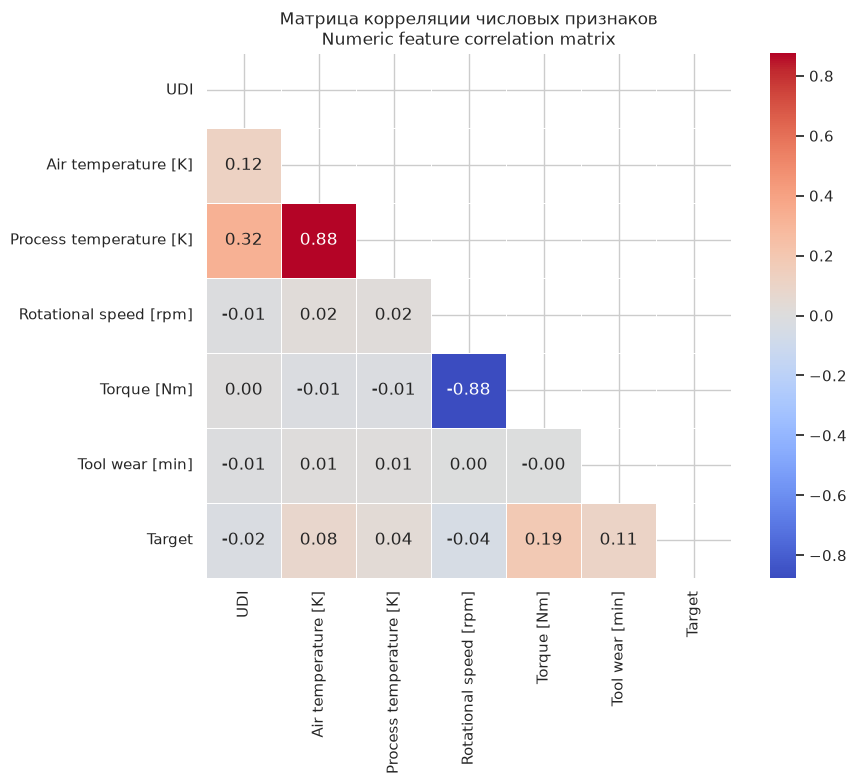

In [26]:
# Выбираем числовые признаки / Select numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

# Heatmap / Тепловая карта
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # верхний треугольник / upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Матрица корреляции числовых признаков\nNumeric feature correlation matrix")
plt.tight_layout()
plt.show()

## 5. Распределение целевой переменной / Target variable distribution

В данном датасете бинарная метка отказа хранится в столбце **`Target`** (0 — нет отказа, 1 — отказ).  
In this dataset, the binary failure label is in **`Target`** (0 = no failure, 1 = failure).

In [27]:
# Подсчёт классов / Class counts
class_counts = df[TARGET_COL].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

print("Распределение целевой переменной / Target distribution:")
for label, count in class_counts.items():
    label_name = TARGET_DISPLAY_LABELS[int(label)]
    print(f"  {label_name}: {count:,} ({class_pct[label]}%)")

print(f"\nДисбаланс классов / Class imbalance ratio: {class_counts[0] / class_counts[1]:.1f} : 1")


Распределение целевой переменной / Target distribution:
  Target=0 (нет отказа): 9,661 (96.61%)
  Target=1 (отказ): 339 (3.39%)

Дисбаланс классов / Class imbalance ratio: 28.5 : 1


/tmp/ipykernel_6395/1633748869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=TARGET_COL, ax=axes[0], palette=TARGET_COLORS)
/tmp/ipykernel_6395/1633748869.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(TARGET_DISPLAY_LABELS)


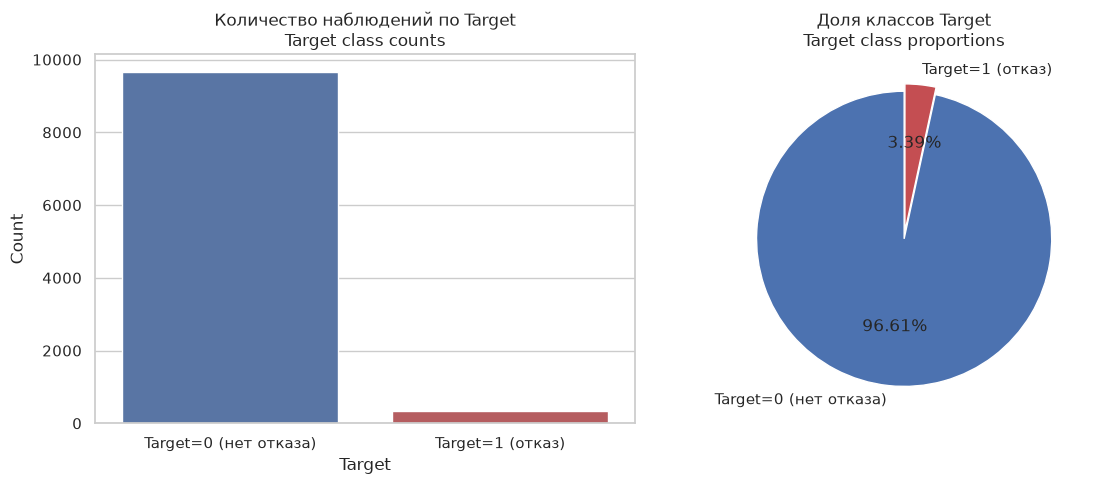

In [28]:
# Визуализация: countplot + pie chart / Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Столбчатая диаграмма / Bar chart
sns.countplot(data=df, x=TARGET_COL, ax=axes[0], palette=TARGET_COLORS)
axes[0].set_title("Количество наблюдений по Target\nTarget class counts")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(TARGET_DISPLAY_LABELS)

# Круговая диаграмма / Pie chart
axes[1].pie(
    class_counts,
    labels=TARGET_DISPLAY_LABELS,
    autopct="%1.2f%%",
    colors=TARGET_COLORS,
    startangle=90,
    explode=(0, 0.05),
)
axes[1].set_title("Доля классов Target\nTarget class proportions")

plt.tight_layout()
plt.show()


Типы отказов (Failure Type) среди случаев с Target=1:
Failure Type
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
No Failure                    9
Name: count, dtype: int64


/tmp/ipykernel_6395/1402141612.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_types.index, y=failure_types.values, ax=ax, palette="Reds_r")


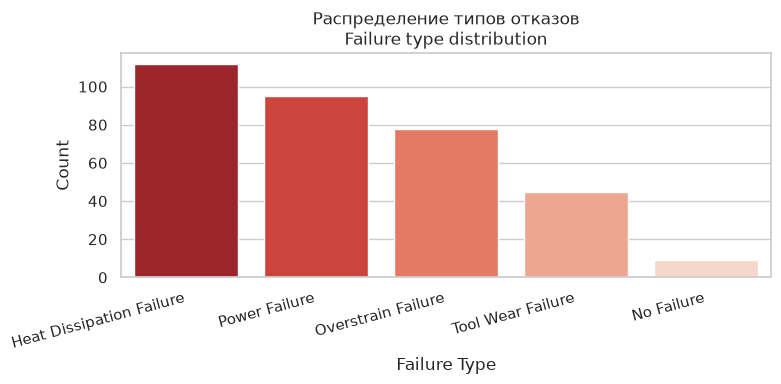

In [29]:
# Типы отказов среди положительного класса / Failure types among positive class
if FAILURE_TYPE_COL in df.columns:
    failure_types = (
        df.loc[df[TARGET_COL] == 1, FAILURE_TYPE_COL]
        .value_counts()
    )
    print("Типы отказов (Failure Type) среди случаев с Target=1:")
    print(failure_types)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=failure_types.index, y=failure_types.values, ax=ax, palette="Reds_r")
    ax.set_title("Распределение типов отказов\nFailure type distribution")
    ax.set_xlabel(FAILURE_TYPE_COL)
    ax.set_ylabel("Count")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()


## 6. Предобработка данных для моделирования / Data preprocessing for modeling

Подготовка признаков перед обучением: кодирование категорий, разбиение на train/test и стандартизация числовых столбцов.  
Feature preparation before training: categorical encoding, train/test split, and numeric standardization.

In [34]:
# 1. Копия данных — исходный df не изменяем / Copy — keep original df intact
df_model = df.copy()

# 2. Целевая переменная y = Target / Target variable
y = df_model[TARGET_COL]

# 3. Инженерия признаков / Feature engineering
# Product ID: первые 2 символа — подтип продукта (L4, L5, M1, M2, H2, H3)
# Product ID: first 2 chars encode product sub-type (L4, L5, M1, M2, H2, H3)
df_model[PRODUCT_ID_PREFIX_COL] = df_model[PRODUCT_ID_COL].astype(str).str[:PRODUCT_ID_PREFIX_LEN]

# Признаки X: убираем служебные и целевые колонки / Features X: drop ID, target, leakage
X = df_model.drop(columns=DROP_COLS)

print("Числовые признаки / Numeric features:")
print(NUMERIC_FEATURES)
print("\nКатегориальные признаки / Categorical features:")
print(CATEGORICAL_FEATURES)

# 4. One-Hot Encoding для категориальных признаков / One-hot encode categoricals
X = pd.get_dummies(X, columns=CATEGORICAL_FEATURES, drop_first=False)

# 5. Разбиение train / test / Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,  # сохраняем долю классов Target / preserve Target class ratio
)

# 6. Стандартизация числовых признаков: fit на train, transform на train и test
# Standardize numeric features: fit on train, transform train and test
scaler = StandardScaler()
X_train[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

# XGBoost не принимает [, ] и < в именах колонок (например Air temperature [K])
# XGBoost rejects [, ] and < in column names (e.g. Air temperature [K])
X_train.columns = [str(c).replace("[", "(").replace("]", ")").replace("<", "lt") for c in X_train.columns]
X_test.columns = [str(c).replace("[", "(").replace("]", ")").replace("<", "lt") for c in X_test.columns]

# 7. Размеры выборок и первые строки X_train / Sample sizes and X_train preview
print("\n" + "=" * 50)
print("Размеры выборок / Sample shapes:")
print(f"  X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}  |  y_test: {y_test.shape}")

print("\nПервые 5 строк X_train / First 5 rows of X_train:")
display(X_train.head())

print("\nПредобработка завершена. Данные готовы к обучению моделей.")
print("Preprocessing complete. Data is ready for model training.")


Числовые признаки / Numeric features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Категориальные признаки / Categorical features:
['Type', 'Product_ID_prefix']

Размеры выборок / Sample shapes:
  X_train: (8000, 14)  |  X_test: (2000, 14)
  y_train: (8000,)  |  y_test: (2000,)

Первые 5 строк X_train / First 5 rows of X_train:


,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Type_H,Type_L,Type_M,Product_ID_prefix_H2,Product_ID_prefix_H3,Product_ID_prefix_L4,Product_ID_prefix_L5,Product_ID_prefix_M1,Product_ID_prefix_M2
4058,0.998914,0.604282,-0.460607,0.718305,-0.843997,False,False,True,False,False,False,False,True,False
1221,-1.505194,-1.153260,-0.775574,0.638456,0.382263,False,False,True,False,False,False,False,True,False
6895,0.498092,1.077466,-1.007654,0.558607,0.460870,False,False,True,False,False,False,False,False,True
9863,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,False,True,False,False,False,False,True,False,False
8711,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,False,True,False,False,False,False,True,False,False



Предобработка завершена. Данные готовы к обучению моделей.
Preprocessing complete. Data is ready for model training.


## 7. Baseline-модель: Logistic Regression / Baseline model

Обучаем логистическую регрессию как простую линейную базу для сравнения с более сложными моделями.  
Train logistic regression as a simple linear baseline for later comparison with more complex models.

Метрики Logistic Regression / Logistic Regression metrics:
  Accuracy:  0.9675
  Precision: 0.6364
  Recall:    0.1029
  F1-score:  0.1772


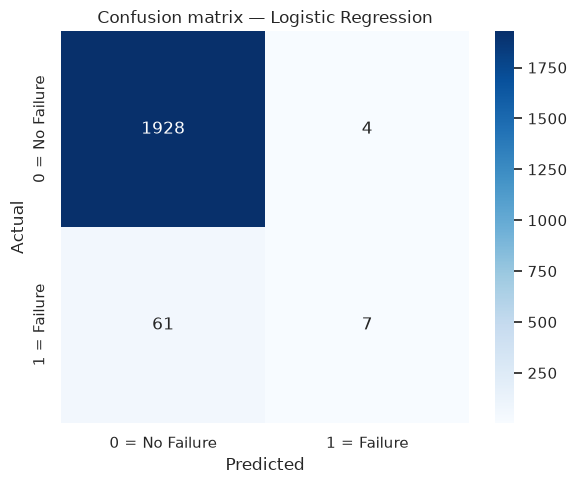

Baseline модель (Logistic Regression). F1-score = 0.18


In [ ]:
# 1. Обучение Logistic Regression / Train Logistic Regression
logreg = LogisticRegression(random_state=RANDOM_STATE, max_iter=LOGREG_MAX_ITER)
logreg.fit(X_train, y_train)

# 2. Предсказания на тесте / Predictions on the test set
y_pred = logreg.predict(X_test)

# 3. Метрики классификации / Classification metrics
# F1 — основная метрика при дисбалансе классов Target / F1 is the primary metric under class imbalance
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
# Сохраняем метрики baseline для итоговой таблицы / Keep baseline metrics for the comparison table
acc_logreg, prec_logreg, rec_logreg, f1_logreg = acc, prec, rec, f1

print("Метрики Logistic Regression / Logistic Regression metrics:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-score:  {f1:.4f}")

# 4. Confusion matrix: тепловая карта / Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=ax,
)
ax.set_title("Confusion matrix — Logistic Regression")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# 5. Краткий итог / Short summary
print(f"Baseline модель (Logistic Regression). F1-score = {f1:.2f}")


## 8. Random Forest / Random Forest

Ансамбль деревьев лучше ловит нелинейные зависимости датчиков; `class_weight='balanced'` повышает вес редкого класса отказа.  
A tree ensemble captures nonlinear sensor patterns; `class_weight='balanced'` upweights the rare failure class.

Метрики Random Forest / Random Forest metrics:
  Accuracy:  0.9780
  Precision: 0.7069
  Recall:    0.6029
  F1-score:  0.6508


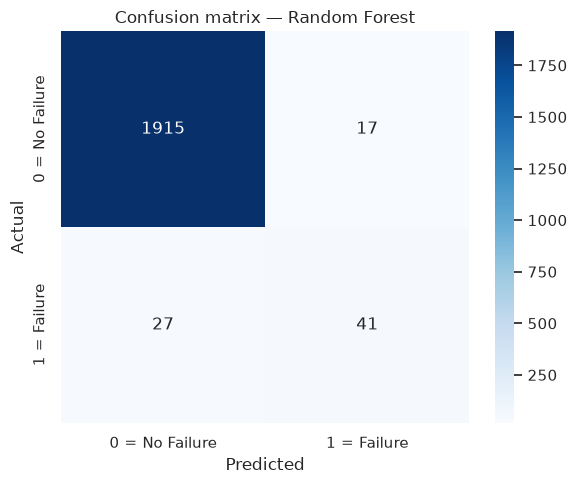

Random Forest model. F1-score = 0.65
Improvement vs baseline: +0.47 F1-points


In [ ]:
# 1. Обучение Random Forest / Train Random Forest
# n_estimators — число деревьев; class_weight='balanced' — веса классов обратно пропорциональны частоте
# n_estimators is the number of trees; class_weight='balanced' scales class weights by inverse frequency
rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    random_state=RANDOM_STATE,
    class_weight=CLASS_WEIGHT,
)
rf.fit(X_train, y_train)

# 2. Предсказания на тесте / Predictions on the test set
y_pred_rf = rf.predict(X_test)

# 3. Метрики классификации / Classification metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print("Метрики Random Forest / Random Forest metrics:")
print(f"  Accuracy:  {acc_rf:.4f}")
print(f"  Precision: {prec_rf:.4f}")
print(f"  Recall:    {rec_rf:.4f}")
print(f"  F1-score:  {f1_rf:.4f}")

# 4. Confusion matrix: тепловая карта / Confusion matrix heatmap
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=ax,
)
ax.set_title("Confusion matrix — Random Forest")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

# 5. Краткий итог / Short summary
print(f"Random Forest model. F1-score = {f1_rf:.2f}")

# 6. Сравнение с Logistic Regression / Comparison vs baseline
f1_delta = f1_rf - f1_logreg
print(f"Improvement vs baseline: {f1_delta:+.2f} F1-points")

## 9. XGBoost / XGBoost

Градиентный бустинг часто сильнее случайного леса на табличных данных; `scale_pos_weight` компенсирует редкий класс отказа.  
Gradient boosting is often stronger than a random forest on tabular data; `scale_pos_weight` offsets the rare failure class.

scale_pos_weight (train): 7729 / 271 = 28.52
Метрики XGBoost / XGBoost metrics:
  Accuracy:  0.9750
  Precision: 0.6047
  Recall:    0.7647
  F1-score:  0.6753


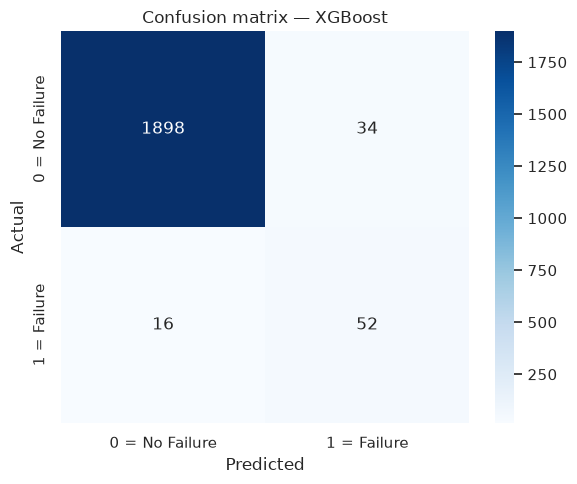

XGBoost model. F1-score = 0.68


,Модель,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772
1,Random Forest,0.9780,0.7069,0.6029,0.6508
2,XGBoost,0.9750,0.6047,0.7647,0.6753


Лучшая модель для этой задачи — XGBoost (F1-score = 0.68). Класс отказа редкий, поэтому ориентируемся на F1, а не на Accuracy: линейный baseline хуже ловит нелинейные сочетания датчиков, а деревья/бустинг учитывают дисбаланс через class_weight / scale_pos_weight и лучше отделяют отказ от нормальной работы.
Best model for this task is XGBoost (F1-score = 0.68). Failures are rare, so F1 is preferred over Accuracy. A linear baseline misses nonlinear sensor interactions, while tree models handle imbalance and capture those patterns more effectively.


In [39]:
# 1. Обучение XGBoost / Train XGBoost
# scale_pos_weight = n(класс 0) / n(класс 1) на train — без утечки из теста
# scale_pos_weight = n(class 0) / n(class 1) on train — no test leakage
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (train): {n_neg} / {n_pos} = {scale_pos_weight:.2f}")

# XGBoost не принимает [, ] и < в именах признаков (Air temperature [K] и т.п.)
# XGBoost rejects [, ] and < in feature names (e.g. Air temperature [K])
def sanitize_xgb_columns(columns):
    return [str(c).replace("[", "(").replace("]", ")").replace("<", "lt") for c in columns]


X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()
X_train_xgb.columns = sanitize_xgb_columns(X_train_xgb.columns)
X_test_xgb.columns = sanitize_xgb_columns(X_test_xgb.columns)

xgb = XGBClassifier(
    n_estimators=XGB_N_ESTIMATORS,
    learning_rate=XGB_LEARNING_RATE,
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
)
xgb.fit(X_train_xgb, y_train)

# 2. Предсказания на тесте / Predictions on the test set
y_pred_xgb = xgb.predict(X_test_xgb)

# 3. Метрики классификации / Classification metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
rec_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)

print("Метрики XGBoost / XGBoost metrics:")
print(f"  Accuracy:  {acc_xgb:.4f}")
print(f"  Precision: {prec_xgb:.4f}")
print(f"  Recall:    {rec_xgb:.4f}")
print(f"  F1-score:  {f1_xgb:.4f}")

# 4. Confusion matrix: тепловая карта / Confusion matrix heatmap
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=ax,
)
ax.set_title("Confusion matrix — XGBoost")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"XGBoost model. F1-score = {f1_xgb:.2f}")

# 5. Сравнение трёх моделей / Compare all three models
# F1 — главная метрика: Accuracy завышен из-за дисбаланса (~3.4% отказов)
# F1 is the primary metric: Accuracy is inflated by class imbalance (~3.4% failures)
metrics_df = pd.DataFrame(
    {
        "Модель": ["Logistic Regression", "Random Forest", "XGBoost"],
        "Accuracy": [acc_logreg, acc_rf, acc_xgb],
        "Precision": [prec_logreg, prec_rf, prec_xgb],
        "Recall": [rec_logreg, rec_rf, rec_xgb],
        "F1-score": [f1_logreg, f1_rf, f1_xgb],
    }
)
display(metrics_df.round(4))

# 6. Краткий вывод / Short conclusion
best_row = metrics_df.loc[metrics_df["F1-score"].idxmax()]
best_name = best_row["Модель"]
best_f1 = best_row["F1-score"]
print(
    f"Лучшая модель для этой задачи — {best_name} (F1-score = {best_f1:.2f}). "
    "Класс отказа редкий, поэтому ориентируемся на F1, а не на Accuracy: "
    "линейный baseline хуже ловит нелинейные сочетания датчиков, "
    "а деревья/бустинг учитывают дисбаланс через class_weight / scale_pos_weight "
    "и лучше отделяют отказ от нормальной работы."
)
print(
    f"Best model for this task is {best_name} (F1-score = {best_f1:.2f}). "
    "Failures are rare, so F1 is preferred over Accuracy. "
    "A linear baseline misses nonlinear sensor interactions, while tree models "
    "handle imbalance and capture those patterns more effectively."
)

## 10. Подбор гиперпараметров XGBoost / XGBoost hyperparameter tuning

Небольшая сетка + `GridSearchCV` по F1, чтобы усилить базовый XGBoost без долгого перебора.  
A small grid with `GridSearchCV` on F1 to strengthen the base XGBoost without a long search.

Сетка параметров / Parameter grid:
{'n_estimators': [50, 100], 'max_depth': [3, 6], 'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0]}
scale_pos_weight (фиксирован / fixed): 28.52
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Лучшие параметры / Best parameters:
{'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 1.0}
Лучший F1 на CV / Best CV F1-score: 0.6928

Метрики XGBoost Tuned / XGBoost Tuned metrics:
  Accuracy:  0.9760
  Precision: 0.6190
  Recall:    0.7647
  F1-score:  0.6842


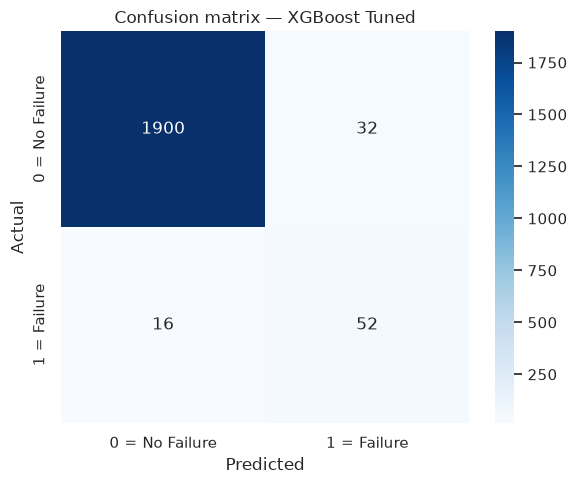

XGBoost Tuned model. F1-score = 0.68


,Модель,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772
1,Random Forest,0.9780,0.7069,0.6029,0.6508
2,XGBoost,0.9750,0.6047,0.7647,0.6753
3,XGBoost Tuned,0.9760,0.6190,0.7647,0.6842


Для продакшена рекомендуется XGBoost Tuned (F1-score = 0.68 на тесте). Основная метрика — F1: отказов мало (~3.4%), Accuracy легко завысить. Logistic Regression слишком простой для нелинейных сочетаний датчиков. Random Forest устойчив, но обычно слабее бустинга. XGBoost Tuned подбирает глубину, шаг обучения и subsample по F1 на CV, сохраняет scale_pos_weight=28.52 и лучше балансирует пропуски отказов и ложные тревоги.
For production, XGBoost Tuned is recommended (test F1-score = 0.68). F1 is the decision metric because failures are rare (~3.4%) and Accuracy is misleading. Logistic Regression misses nonlinear sensor interactions. Random Forest is stable but usually weaker than boosting. XGBoost Tuned selects depth, learning rate, and subsample by CV F1, keeps scale_pos_weight=28.52, and better balances missed failures vs false alarms.


In [ ]:
# 1. Сетка гиперпараметров (16 комбинаций × 3 фолда = 48 обучений)
# Hyperparameter grid (16 combinations × 3 folds = 48 fits)
print("Сетка параметров / Parameter grid:")
print(XGB_PARAM_GRID)
print(f"scale_pos_weight (фиксирован / fixed): {XGB_SCALE_POS_WEIGHT}")

# Базовая модель: дисбаланс не крутим в сетке, оставляем тот же вес положительного класса
# Base model: keep the same positive-class weight, do not search it
xgb_base = XGBClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=XGB_SCALE_POS_WEIGHT,
    eval_metric="logloss",
    n_jobs=1,  # параллелизм отдаём GridSearchCV / let GridSearchCV use the cores
)

# 2. GridSearchCV: максимизируем F1, 3 фолда, все ядра CPU
# GridSearchCV: maximize F1, 3-fold CV, all CPU cores
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=XGB_PARAM_GRID,
    scoring="f1",
    cv=CV_FOLDS,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

# 3. Лучшие параметры и F1 на кросс-валидации / Best params and CV F1
print("\nЛучшие параметры / Best parameters:")
print(grid_search.best_params_)
print(f"Лучший F1 на CV / Best CV F1-score: {grid_search.best_score_:.4f}")

# 4. Оценка лучшей модели на тесте / Evaluate the best model on the test set
xgb_tuned = grid_search.best_estimator_
y_pred_xgb_tuned = xgb_tuned.predict(X_test)

acc_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
prec_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned, zero_division=0)
rec_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned, zero_division=0)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned, zero_division=0)

print("\nМетрики XGBoost Tuned / XGBoost Tuned metrics:")
print(f"  Accuracy:  {acc_xgb_tuned:.4f}")
print(f"  Precision: {prec_xgb_tuned:.4f}")
print(f"  Recall:    {rec_xgb_tuned:.4f}")
print(f"  F1-score:  {f1_xgb_tuned:.4f}")

# 5. Confusion matrix / Матрица ошибок
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    ax=ax,
)
ax.set_title("Confusion matrix — XGBoost Tuned")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"XGBoost Tuned model. F1-score = {f1_xgb_tuned:.2f}")

# 6. Итоговая таблица всех 4 моделей / Final comparison of all 4 models
metrics_all = pd.DataFrame(
    {
        "Модель": ["Logistic Regression", "Random Forest", "XGBoost", "XGBoost Tuned"],
        "Accuracy": [acc_logreg, acc_rf, acc_xgb, acc_xgb_tuned],
        "Precision": [prec_logreg, prec_rf, prec_xgb, prec_xgb_tuned],
        "Recall": [rec_logreg, rec_rf, rec_xgb, rec_xgb_tuned],
        "F1-score": [f1_logreg, f1_rf, f1_xgb, f1_xgb_tuned],
    }
)
display(metrics_all.round(4))

# 7. Рекомендация для продакшена / Production recommendation
best_row = metrics_all.loc[metrics_all["F1-score"].idxmax()]
best_name = best_row["Модель"]
best_f1 = best_row["F1-score"]
print(
    f"Для продакшена рекомендуется {best_name} (F1-score = {best_f1:.2f} на тесте). "
    "Основная метрика — F1: отказов мало (~3.4%), Accuracy легко завысить. "
    "Logistic Regression слишком простой для нелинейных сочетаний датчиков. "
    "Random Forest устойчив, но обычно слабее бустинга. "
    "XGBoost Tuned подбирает глубину, шаг обучения и subsample по F1 на CV, "
    "сохраняет scale_pos_weight=28.52 и лучше балансирует пропуски отказов и ложные тревоги."
)
print(
    f"For production, {best_name} is recommended (test F1-score = {best_f1:.2f}). "
    "F1 is the decision metric because failures are rare (~3.4%) and Accuracy is misleading. "
    "Logistic Regression misses nonlinear sensor interactions. "
    "Random Forest is stable but usually weaker than boosting. "
    "XGBoost Tuned selects depth, learning rate, and subsample by CV F1, "
    "keeps scale_pos_weight=28.52, and better balances missed failures vs false alarms."
)

## 11. Сохранение лучшей модели / Save the best model

Сохраняем XGBoost Tuned вместе со scaler и списком колонок, чтобы `src/predict.py` повторил ту же предобработку.  
Save XGBoost Tuned plus the scaler and column list so `src/predict.py` can replay the same preprocessing.

In [42]:
# Сохраняем артефакт инференса: модель + scaler + схема признаков
# Save inference artifact: model + scaler + feature schema
MODELS_DIR.mkdir(parents=True, exist_ok=True)

inference_artifact = {
    "model": xgb_tuned,
    "scaler": scaler,
    "feature_names": list(X_train.columns),  # колонки после OHE и sanitize / columns after OHE and sanitize
    "numeric_features": NUMERIC_FEATURES,  # исходные имена для scaler / original names used by scaler
    "categorical_features": CATEGORICAL_FEATURES,
    "product_id_col": PRODUCT_ID_COL,
    "product_id_prefix_col": PRODUCT_ID_PREFIX_COL,
    "product_id_prefix_len": PRODUCT_ID_PREFIX_LEN,
    "drop_cols": DROP_COLS,
}

joblib.dump(inference_artifact, MODEL_PATH)
print(f"Модель сохранена / Model saved: {MODEL_PATH}")
print(f"Размер файла / File size: {MODEL_PATH.stat().st_size / 1024:.1f} KB")

Модель сохранена / Model saved: /home/ichy5/Pet-proj/models/best_model.pkl
Размер файла / File size: 298.6 KB
